In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Qiskit & Optimization imports
from qiskit_aer import AerSimulator
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

In [2]:
tickers = ['BBCA.JK', 'TLKM.JK', 'ASII.JK', 'BMRI.JK']
data = yf.download(tickers, start='2024-01-01', end='2025-01-01')['Close']

# Hitung expected return tahunan dan matriks kovariansi
daily_returns = data.pct_change().dropna()
mu = daily_returns.mean().values * 252       # Expected return
sigma = daily_returns.cov().values * 252      # Covariance matrix

print("Expected Returns (μ):", np.round(mu, 4))
print("\nCovariance Matrix (Σ):\n", np.round(sigma, 4))

[*********************100%***********************]  4 of 4 completed

Expected Returns (μ): [-0.0146  0.0822  0.0229 -0.3059]

Covariance Matrix (Σ):
 [[0.0676 0.018  0.0249 0.0252]
 [0.018  0.0496 0.0361 0.0159]
 [0.0249 0.0361 0.0928 0.0212]
 [0.0252 0.0159 0.0212 0.0876]]


In [3]:
num_assets = len(tickers)
q = 0.5       # Faktor risiko: 0 = agresif, 1 = defensif (risk-averse)
budget = 2    # Jumlah saham yang ingin dipilih

# Inisialisasi program kuadratik
qp = QuadraticProgram(name="Portfolio_Optimization")

# 1. Buat variabel keputusan biner untuk masing-masing saham (0: tidak beli, 1: beli)
for ticker in tickers:
    qp.binary_var(name=ticker)

# 2. Rumuskan Objective Function: Minimalkan Risiko - Maksimalkan Return
# Min: q * (x^T * Sigma * x) - (mu^T * x)
linear_terms = {tickers[i]: -float(mu[i]) for i in range(num_assets)}

quadratic_terms = {}
for i in range(num_assets):
    for j in range(num_assets):
        val = q * float(sigma[i, j])
        if val != 0:
            quadratic_terms[(tickers[i], tickers[j])] = val

qp.minimize(linear=linear_terms, quadratic=quadratic_terms)

# 3. Batasan Budget (Constraint): Jumlah saham yang dipilih harus sama dengan budget
qp.linear_constraint(
    linear={ticker: 1 for ticker in tickers},
    sense="==",
    rhs=budget,
    name="budget_constraint"
)

print(qp.prettyprint())

Problem name: Portfolio_Optimization

Minimize
  0.04639471768117303*ASII.JK^2 + 0.021239527647334593*ASII.JK*BMRI.JK
  + 0.024935583414528572*BBCA.JK*ASII.JK + 0.03380253155845485*BBCA.JK^2
  + 0.02515459682665181*BBCA.JK*BMRI.JK + 0.018038008789199964*BBCA.JK*TLKM.JK
  + 0.0437846693680915*BMRI.JK^2 + 0.0361261085949534*TLKM.JK*ASII.JK
  + 0.015868100552805197*TLKM.JK*BMRI.JK + 0.024811988174191266*TLKM.JK^2
  - 0.022904070412250465*ASII.JK + 0.01463796986108423*BBCA.JK
  + 0.305869866148766*BMRI.JK - 0.0822471201088441*TLKM.JK

Subject to
  Linear constraints (1)
    ASII.JK + BBCA.JK + BMRI.JK + TLKM.JK == 2  'budget_constraint'

  Binary variables (4)
    BBCA.JK TLKM.JK ASII.JK BMRI.JK



In [4]:
from qiskit_algorithms import NumPyMinimumEigensolver

exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
result_exact = exact_solver.solve(qp)

print("=== Hasil Solver Klasik ===")
print("Status:", result_exact.status)
print("Aset Terpilih (Binary):", result_exact.x)
print("Nilai Objektif Markowitz:", result_exact.fval)

=== Hasil Solver Klasik ===
Status: OptimizationResultStatus.SUCCESS
Aset Terpilih (Binary): [0. 1. 1. 0.]
Nilai Objektif Markowitz: 0.0021816239292231365


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import Statevector
from qiskit_optimization.converters import QuadraticProgramToQubo

# 1. Konversi model Markowitz (QP) ke QUBO lalu ke Ising Hamiltonian
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)
operator, offset = qubo.to_ising()

# 2. Bangun Sirkuit QAOA (layer p=1)
p = 1
ansatz = QAOAAnsatz(cost_operator=operator, reps=p)

# 3. Definisikan fungsi objektif energi <psi|H|psi> untuk optimizer klasik
def cost_func(params):
    # Pasang parameter sudut (gamma, beta) ke sirkuit
    circuit = ansatz.assign_parameters(params)
    state = Statevector.from_instruction(circuit)
    # Evaluasi nilai ekspektasi energi Hamiltonian
    return state.expectation_value(operator).real

# 4. Optimasi sudut klasik (COBYLA)
initial_params = np.ones(ansatz.num_parameters) * 0.5
opt_result = minimize(cost_func, initial_params, method='COBYLA', options={'maxiter': 100})

# 5. Ekstrak bitstring portofolio terbaik dari statevector optimal
optimal_circuit = ansatz.assign_parameters(opt_result.x)
final_state = Statevector.from_instruction(optimal_circuit)
probabilities = final_state.probabilities_dict()

# Cari bitstring dengan probabilitas kemunculan tertinggi
best_bitstring = max(probabilities, key=probabilities.get)

# Mapping bitstring Qiskit (little-endian) ke urutan aset
result_qaoa_x = np.array([int(bit) for bit in reversed(best_bitstring)])
result_qaoa_fval = qp.objective.evaluate(result_qaoa_x)

print("=== Hasil QAOA ===")
print("Optimal Parameters (γ, β):", np.round(opt_result.x, 4))
print("Aset Terpilih (Binary)  :", result_qaoa_x)
print("Nilai Objektif Markowitz :", round(result_qaoa_fval, 4))
print("Status Constraint        :", "Valid (Budget Terpenuhi)" if qp.is_feasible(result_qaoa_x) else "Infeasible")

c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


=== Hasil QAOA ===
Optimal Parameters (γ, β): [1.2836 1.5329]
Aset Terpilih (Binary)  : [0 1 1 0]
Nilai Objektif Markowitz : 0.0022
Status Constraint        : Valid (Budget Terpenuhi)


=== BENCHMARK PERBANDINGAN ===
Pilihan Klasik (Exact) : ['TLKM.JK', 'ASII.JK'] (Obj: 0.0022)
Pilihan Kuantum (QAOA) : ['TLKM.JK', 'ASII.JK'] (Obj: 0.0022)
Solusi Identik         : YA (Optimal 100%)


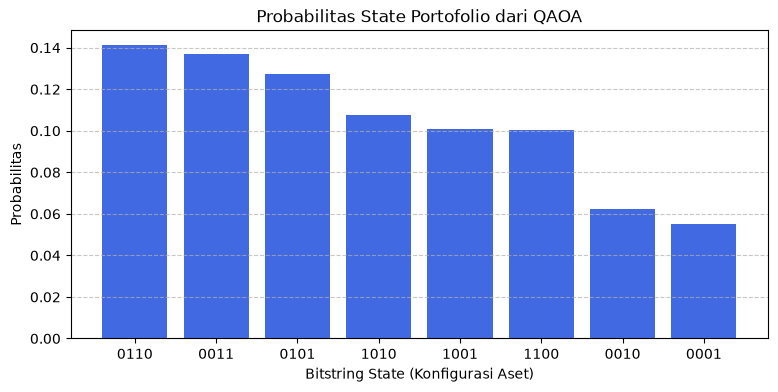

In [6]:
# 1. Tampilkan Perbandingan Aset
selected_exact = [tickers[i] for i, val in enumerate(result_exact.x) if val == 1]
selected_qaoa = [tickers[i] for i, val in enumerate(result_qaoa_x) if val == 1]

print("=== BENCHMARK PERBANDINGAN ===")
print(f"Pilihan Klasik (Exact) : {selected_exact} (Obj: {result_exact.fval:.4f})")
print(f"Pilihan Kuantum (QAOA) : {selected_qaoa} (Obj: {result_qaoa_fval:.4f})")
print(f"Solusi Identik         : {'YA (Optimal 100%)' if np.array_equal(result_exact.x, result_qaoa_x) else 'TIDAK (Sub-optimal)'}")

# 2. Visualisasi Distribusi Probabilitas State QAOA
plt.figure(figsize=(9, 4))
top_states = sorted(probabilities.items(), key=lambda item: item[1], reverse=True)[:8]
plt.bar([item[0] for item in top_states], [item[1] for item in top_states], color='royalblue')
plt.title("Probabilitas State Portofolio dari QAOA")
plt.xlabel("Bitstring State (Konfigurasi Aset)")
plt.ylabel("Probabilitas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Sirkuit Kuantum QAOA ===


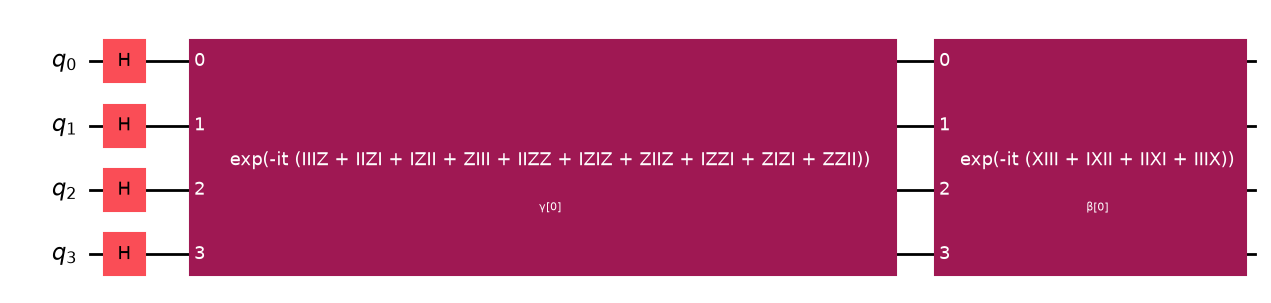

In [7]:
# Tampilkan sirkuit QAOA versi teks / ASCII
print("=== Sirkuit Kuantum QAOA ===")
ansatz.decompose().draw('mpl', fold=-1)

In [8]:
risk_free_rate = 0.06  # Asumsi suku bunga BI 6%

# Ekstrak return dan volatilitas portofolio terpilih (bobot dibagi rata antar aset terpilih)
weights = result_qaoa_x / np.sum(result_qaoa_x)
port_return = np.dot(weights, mu)
port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
sharpe_ratio = (port_return - risk_free_rate) / port_volatility

print("=== METRIK FINANSIAL PORTOFOLIO QAOA ===")
print(f"Alokasi Bobot     : {dict(zip(tickers, np.round(weights, 2)))}")
print(f"Expected Return   : {port_return * 100:.2f}% per tahun")
print(f"Volatilitas (Risk): {port_volatility * 100:.2f}% per tahun")
print(f"Sharpe Ratio      : {sharpe_ratio:.3f}")

=== METRIK FINANSIAL PORTOFOLIO QAOA ===
Alokasi Bobot     : {'BBCA.JK': np.float64(0.0), 'TLKM.JK': np.float64(0.5), 'ASII.JK': np.float64(0.5), 'BMRI.JK': np.float64(0.0)}
Expected Return   : 5.26% per tahun
Volatilitas (Risk): 23.17% per tahun
Sharpe Ratio      : -0.032
